In [1]:
# Importing all necessary libraries
import numpy as np # linear algebra
import pandas as pd # data processing
from matplotlib import pyplot as plt
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)

# Analysis on accidents occuring in different time of a day


In [ ]:
# Extracting the accident data in a day
total_accident_data=pd.read_csv('only_road_accidents_data3.csv')

In [4]:
# Display first 5 rows of the dataset
total_accident_data.head()

,STATE/UT,YEAR,0-3 hrs. (Night),3-6 hrs. (Night),6-9 hrs (Day),9-12 hrs (Day),12-15 hrs (Day),15-18 hrs (Day),18-21 hrs (Night),21-24 hrs (Night),Total
0,A & N Islands,2001,2,6,29,40,39,40,18,7,181
1,A & N Islands,2002,2,6,22,41,33,33,23,8,168
2,A & N Islands,2003,2,8,31,35,28,36,25,15,180
3,A & N Islands,2004,2,5,29,42,43,43,37,14,215
4,A & N Islands,2005,0,8,27,28,38,42,50,13,206


This dataset has data from year 2001 to 2014. Different hours of a day is given how many accidents are occuring in that time.

In [5]:
# checking how many rows and columns
total_accident_data.shape

(490, 11)

The data has 490 rows and 11 columns.

**Basic Information of dataset**

In [6]:
total_accident_data.describe()

,YEAR,0-3 hrs. (Night),3-6 hrs. (Night),6-9 hrs (Day),9-12 hrs (Day),12-15 hrs (Day),15-18 hrs (Day),18-21 hrs (Night),21-24 hrs (Night),Total
count,490.000000,490.000000,490.000000,490.00000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000
mean,2007.500000,796.320408,969.236735,1371.15102,1753.967347,1681.814286,1850.283673,1782.918367,1228.810204,11434.502041
std,4.035249,1210.999326,1415.984501,1864.19157,2400.593532,2326.251665,2643.765262,2587.452453,1836.242850,15948.689470
min,2001.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2004.000000,10.000000,15.000000,36.00000,51.250000,59.250000,59.000000,50.000000,25.250000,357.750000
50%,2007.500000,200.000000,251.500000,498.50000,678.000000,679.500000,669.000000,517.000000,343.500000,4174.500000
75%,2011.000000,1114.250000,1355.250000,2073.75000,2680.500000,2265.500000,2289.000000,2072.000000,1594.750000,16463.500000
max,2014.000000,6020.000000,6545.000000,8241.00000,14568.000000,11089.000000,13789.000000,13927.000000,10364.000000,75480.000000


**Cleaning of Dataset**

In [7]:
# Checking null values in the data
print(total_accident_data.isnull().sum())

STATE/UT             0
YEAR                 0
0-3 hrs. (Night)     0
3-6 hrs. (Night)     0
6-9 hrs (Day)        0
9-12 hrs (Day)       0
12-15 hrs (Day)      0
15-18 hrs (Day)      0
18-21 hrs (Night)    0
21-24 hrs (Night)    0
Total                0
dtype: int64


It has no values which are null or not given so, no need to correcting data.

In [8]:
# All state names used in datasets are
state_names=total_accident_data['STATE/UT'].unique()
print(state_names)

['A & N Islands' 'Andhra Pradesh' 'Arunachal Pradesh' 'Assam' 'Bihar'
 'Chandigarh' 'Chhattisgarh' 'D & N Haveli' 'Daman & Diu' 'Delhi (Ut)'
 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir'
 'Jharkhand' 'Karnataka' 'Kerala' 'Lakshadweep' 'Madhya Pradesh'
 'Maharashtra' 'Manipur' 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha'
 'Puducherry' 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']


All states are unique,no states are repeating so, we can work on dataset.


****Visualization of data****

In [9]:
# plotting no of accidents in year 2000-2014
data_yearly=total_accident_data.groupby('YEAR').sum().reset_index()

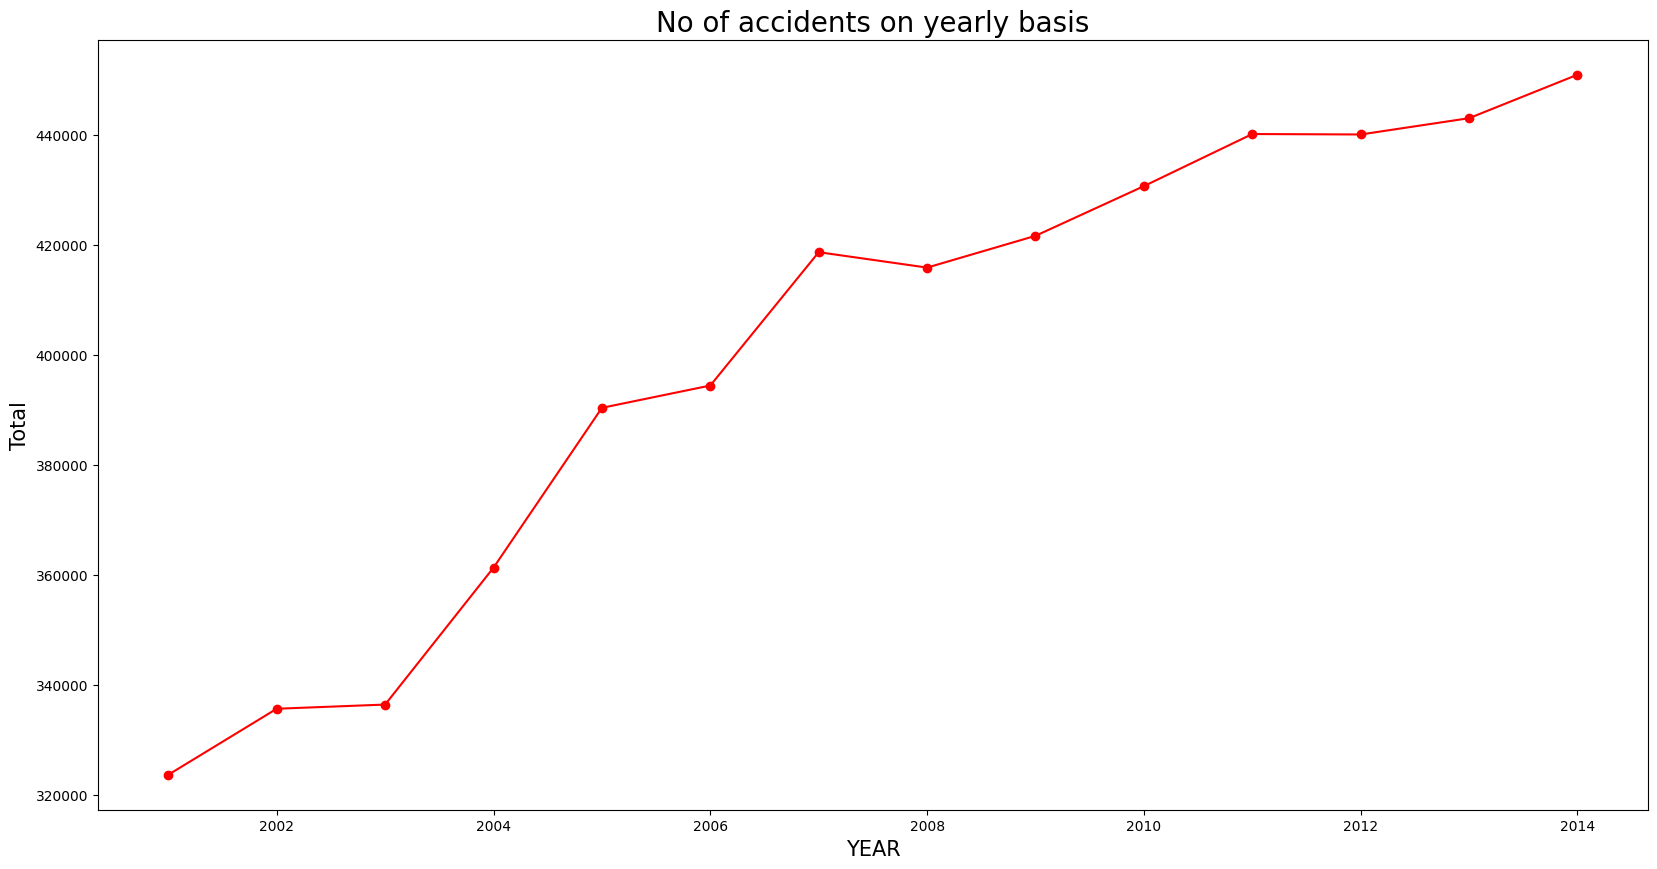

In [10]:
plt.figure(figsize=(20,10))
plt.plot(data_yearly['YEAR'],data_yearly['Total'],color='red',marker='o')
plt.title('No of accidents on yearly basis',size=20)
plt.xlabel('YEAR',size=15)
plt.ylabel('Total',size=15)
plt.show()

From the plot we can see there is a trend that every year number of accidents are increasing rapidly.

In [11]:
# Linear regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x=data_yearly['YEAR'].values
y=data_yearly['Total'].values

In [12]:
lr=LinearRegression()
x_train,x_test,y_train,y_test=train_test_split(x,y)
lr.fit(np.array(x_train).reshape(-1,1),np.array(y_train).reshape(-1,1))

LinearRegression()

In [12]:
lr.intercept_

array([-19044048.2710706])

In [13]:
lr.coef_

array([[9684.66628702]])

In [14]:
# Renaming columns name for easily accessible
total_accident_data.rename(columns={'0-3 hrs. (Night)':'0-3',
                              '3-6 hrs. (Night)':'3-6',
                                '6-9 hrs (Day)':'6-9', '9-12 hrs (Day)':'9-12','12-15 hrs (Day)':'12-15','15-18 hrs (Day)':'15-18',
                                  '18-21 hrs (Night)':'18-21','21-24 hrs (Night)':'21-24','YEAR':'year','STATE/UT':'state/ut'}, inplace=True)

In [15]:
total_accident_data.head()

,state/ut,year,0-3,3-6,6-9,9-12,12-15,15-18,18-21,21-24,Total
0,A & N Islands,2001,2,6,29,40,39,40,18,7,181
1,A & N Islands,2002,2,6,22,41,33,33,23,8,168
2,A & N Islands,2003,2,8,31,35,28,36,25,15,180
3,A & N Islands,2004,2,5,29,42,43,43,37,14,215
4,A & N Islands,2005,0,8,27,28,38,42,50,13,206


**Converting hours data**

In [16]:
# grouping data on basis of state as index
total_accident_day=total_accident_data.groupby(['state/ut']).sum()
# data transforming
total_accident_day['morning']=total_accident_day['6-9']+total_accident_day['9-12']
total_accident_day['afternoon']=total_accident_day['12-15']+total_accident_day['15-18']
total_accident_day['evening']=total_accident_day['18-21']+total_accident_day['21-24']
total_accident_day['night']=total_accident_day['0-3']+total_accident_day['3-6']
total_accident_day['total']=total_accident_day['Total']

****Removing extra columns from the datset****

In [17]:
total_accident_day=total_accident_day.drop(total_accident_day.columns[0:10],axis=1)
total_accident_day.head()

,morning,afternoon,evening,night,total
state/ut,,,,,
A & N Islands,862,1164,753,114,2893
Andhra Pradesh,133178,145782,154202,113659,546821
Arunachal Pradesh,988,1301,725,375,3389
Assam,22870,22405,10647,5796,61718
Bihar,28244,27781,19310,17313,92648


In [18]:
# sorting data with respect to total
max_accident_state=total_accident_day.sort_values(by='total',ascending=False)
max_accident_state.head()

,morning,afternoon,evening,night,total
state/ut,,,,,
Tamil Nadu,223611,263616,236178,128668,852073
Maharashtra,161243,185226,178517,116628,641614
Karnataka,153227,181099,158712,91723,584761
Andhra Pradesh,133178,145782,154202,113659,546821
Kerala,158466,195513,130334,33848,518161


**Plotting total accidents from year 2000-2014 for all States/UT**

Text(0.5, 1.0, 'Total Cases of accident in year 2000-2014')

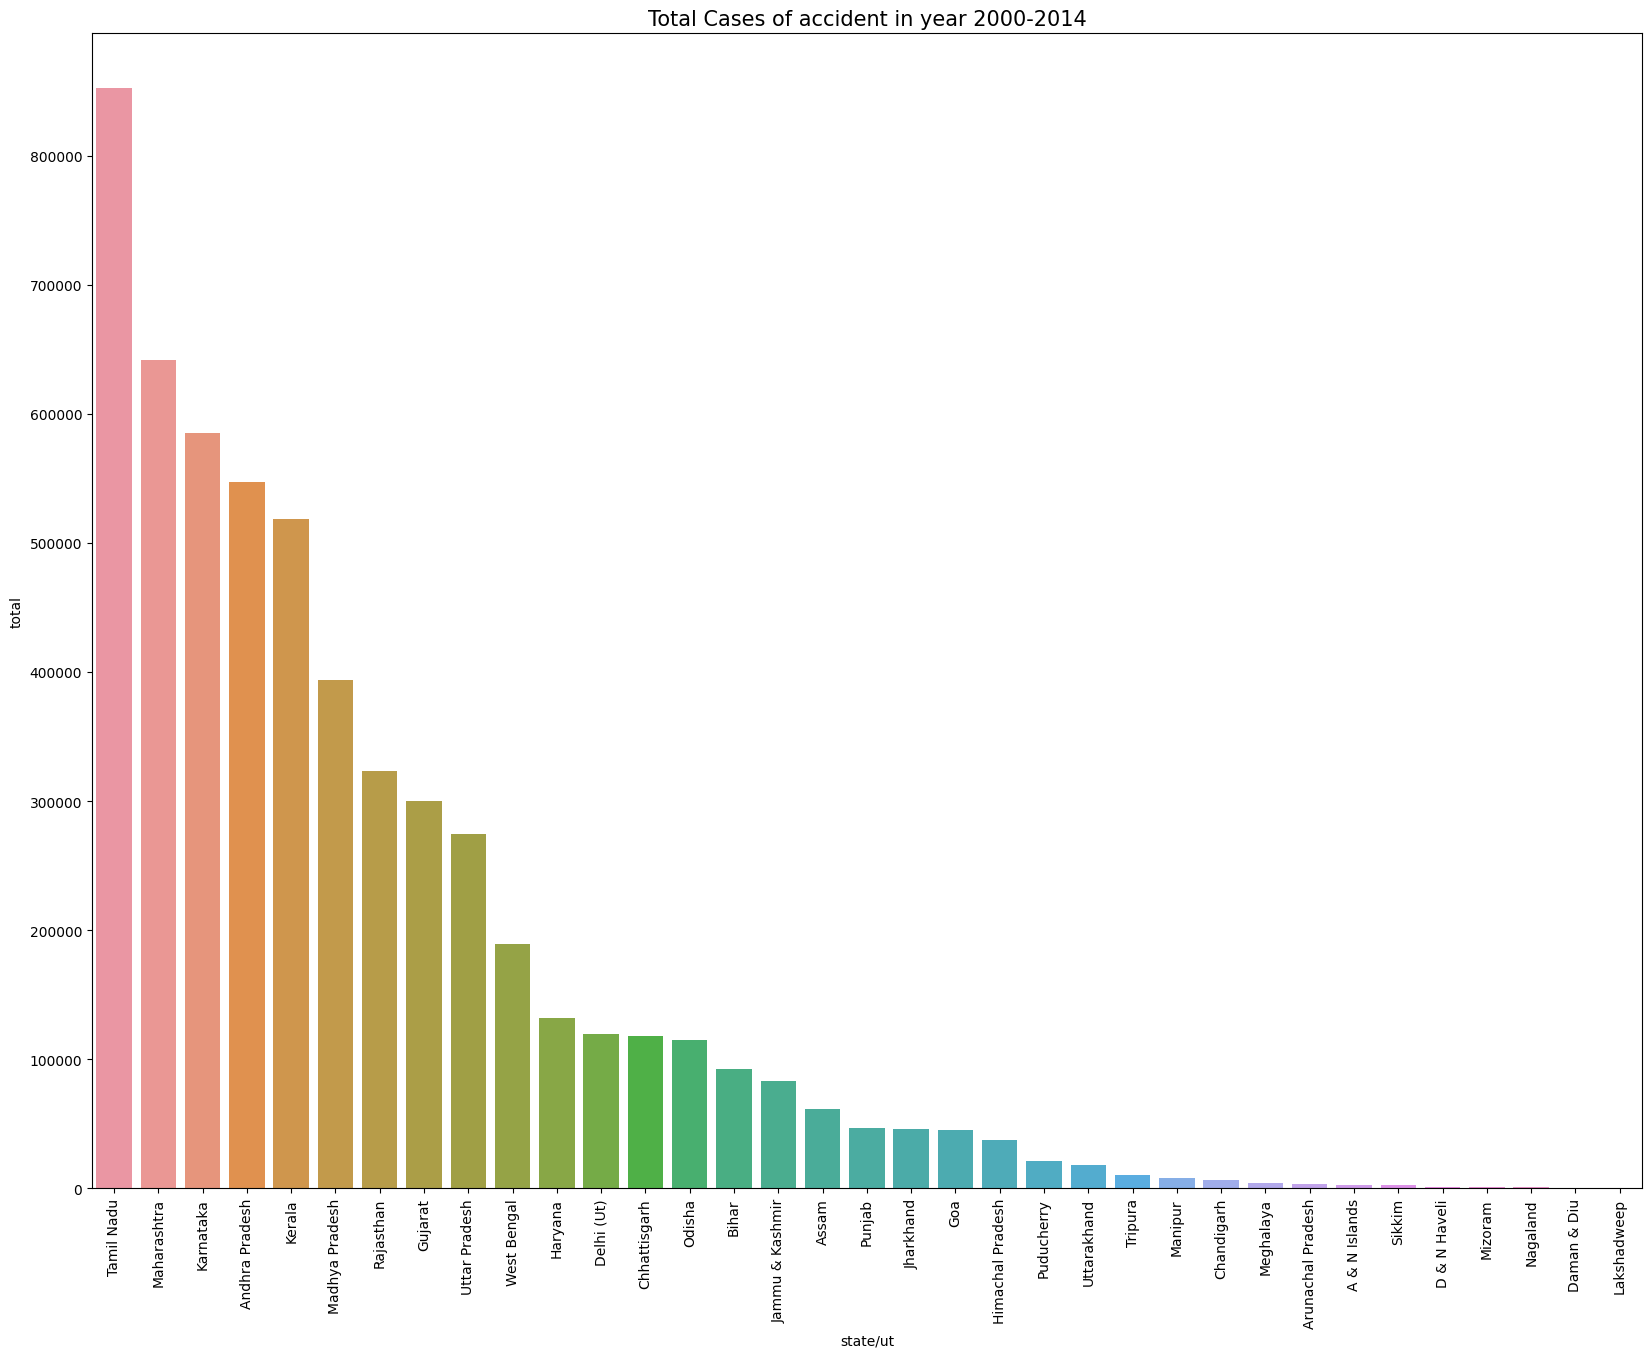

In [19]:
plt.figure(figsize=(20,15))
sns.barplot(x=max_accident_state.index,y='total',data=max_accident_state)
plt.xticks(rotation=90)
plt.title('Total Cases of accident in year 2000-2014',size=15)

Maximum accidents case occured in Tamil Nadu state followed by Maharsahtra,Karnataka and Andhra Pradesh from year 2000 to 2014.

In [20]:
# Top 6 states where maximum accidents occurs per day
top_accident_state=max_accident_state[0:6]
top_accident_state

,morning,afternoon,evening,night,total
state/ut,,,,,
Tamil Nadu,223611,263616,236178,128668,852073
Maharashtra,161243,185226,178517,116628,641614
Karnataka,153227,181099,158712,91723,584761
Andhra Pradesh,133178,145782,154202,113659,546821
Kerala,158466,195513,130334,33848,518161
Madhya Pradesh,117682,127422,94844,54059,394007


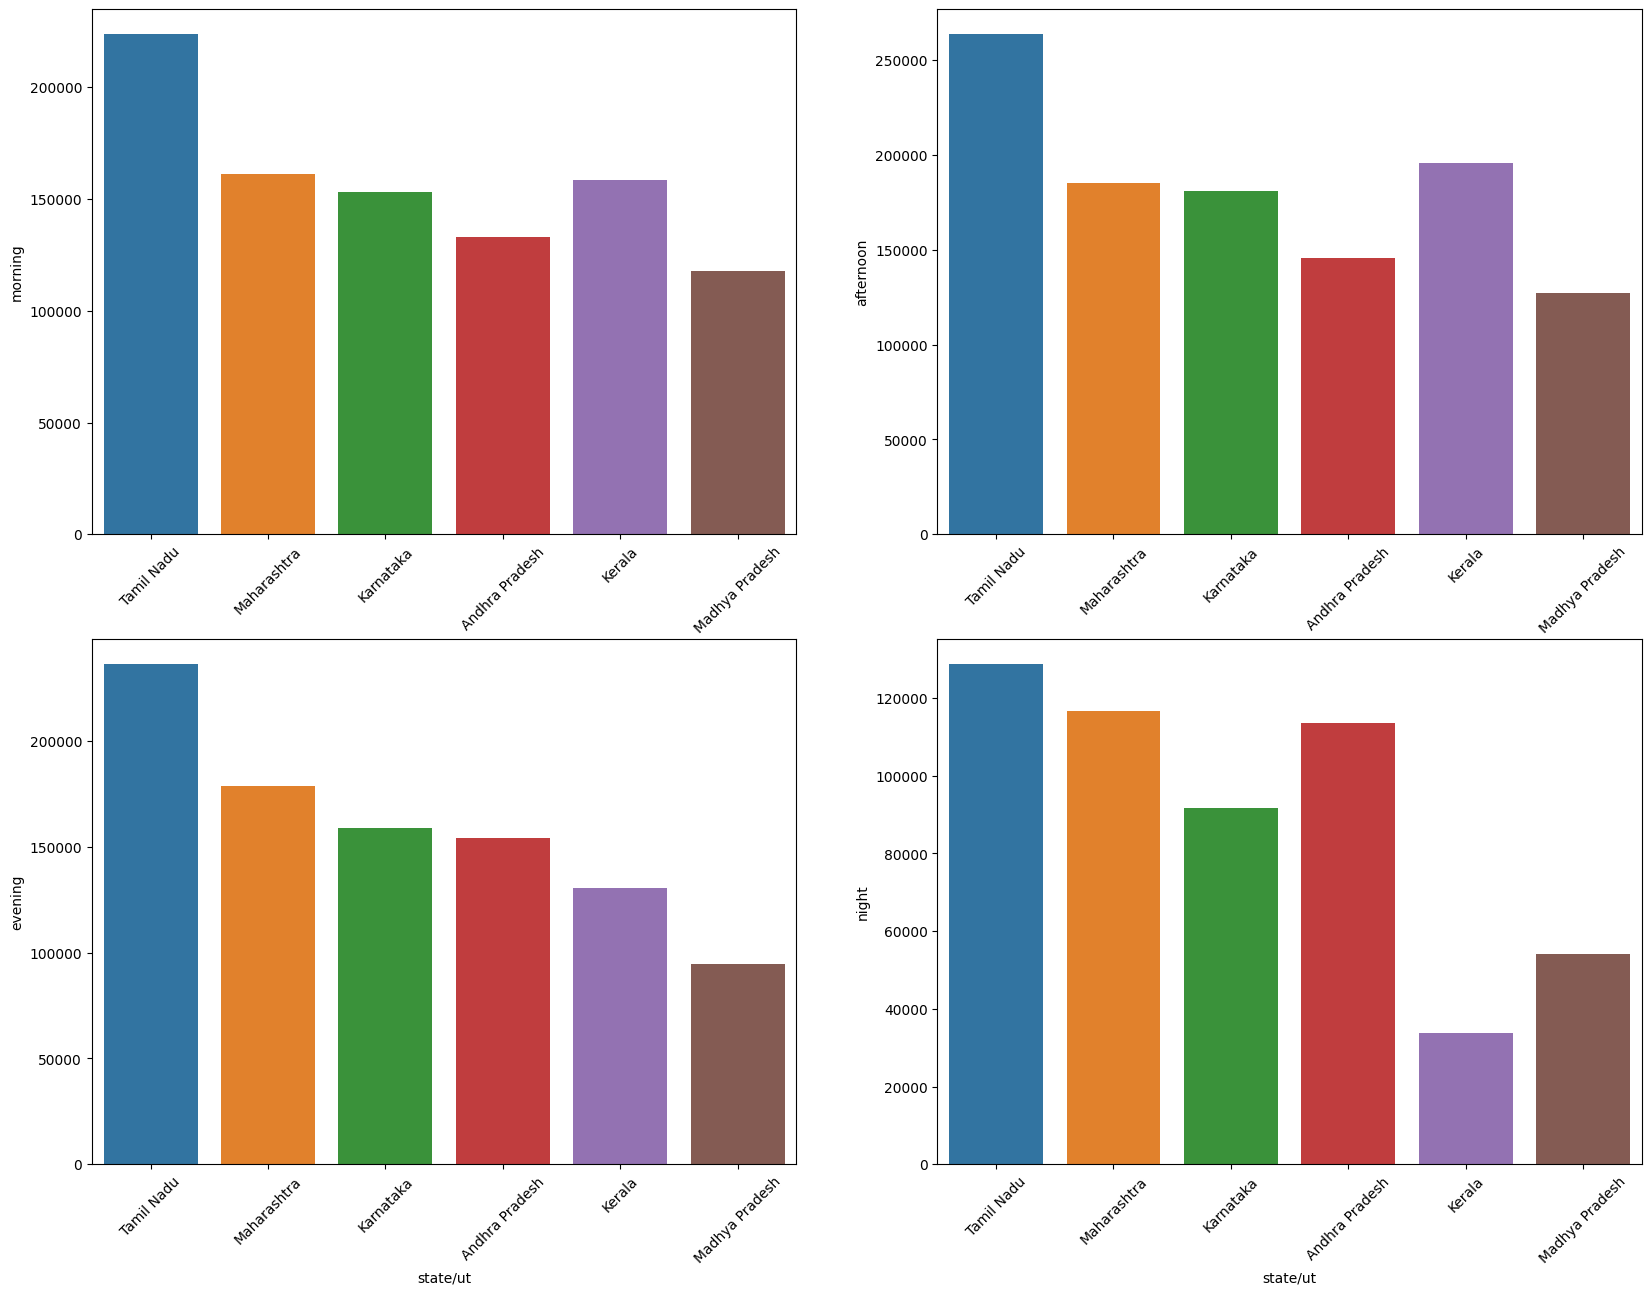

In [21]:
time_column=['morning','afternoon','evening','night']
plt.figure(figsize=(20,15))
for i, col in enumerate(time_column,1):
    plt.subplot(2,2,i)
    sns.barplot(x=top_accident_state.index,y=col,data=top_accident_state)
    plt.xticks(rotation=45)

<Axes: title={'center': 'All accidents in 2001-2014'}>

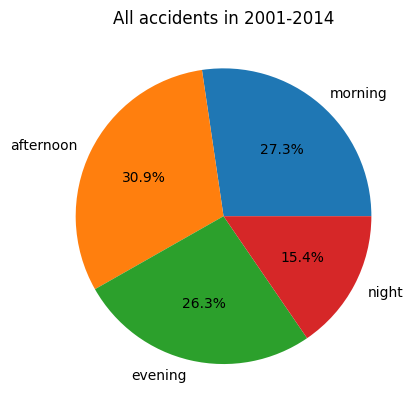

In [22]:
df=total_accident_day.sum(axis=0).drop('total')
df.plot.pie(title='All accidents in 2001-2014',autopct='%0.1f%%')


From the pie chart we can say maximum accidents occur during afternoon time followed by morning beacuse at this time maximum traffic occur.And at evening and night maximum people stay inside home.

C:\Users\abdur rehman\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


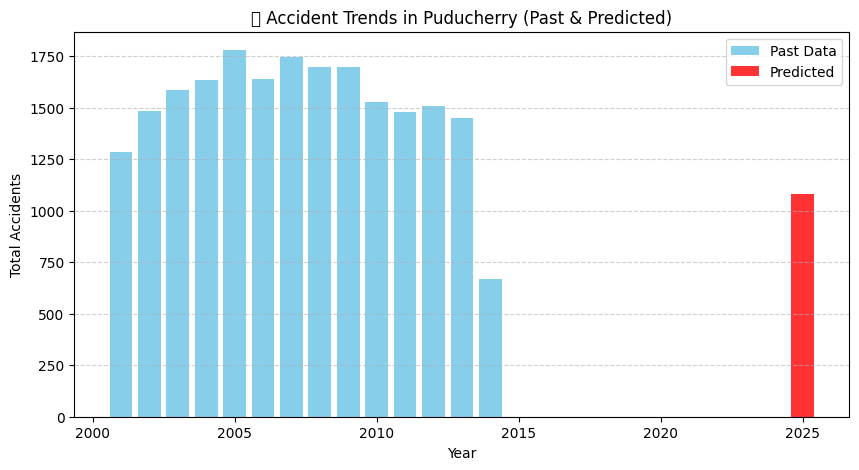

C:\Users\abdur rehman\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


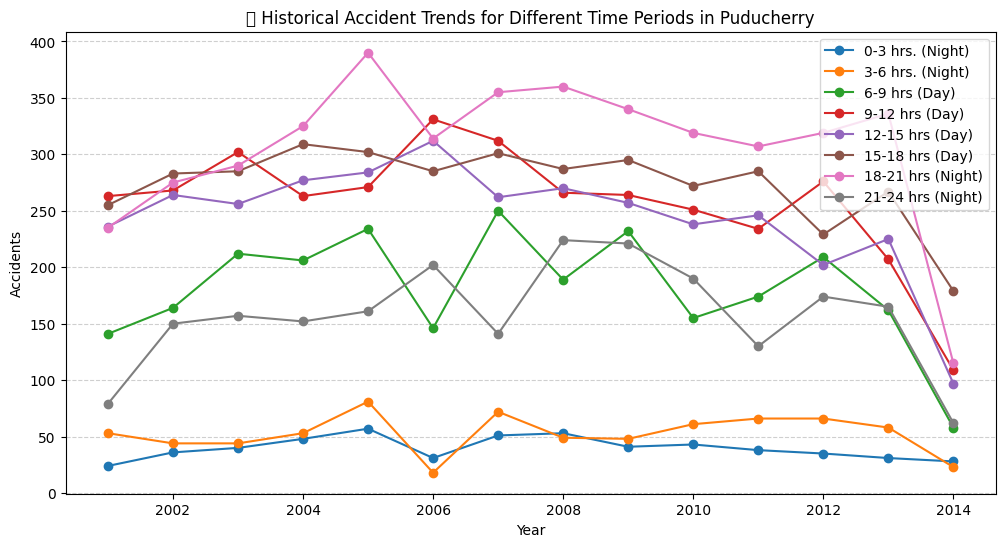

C:\Users\abdur rehman\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


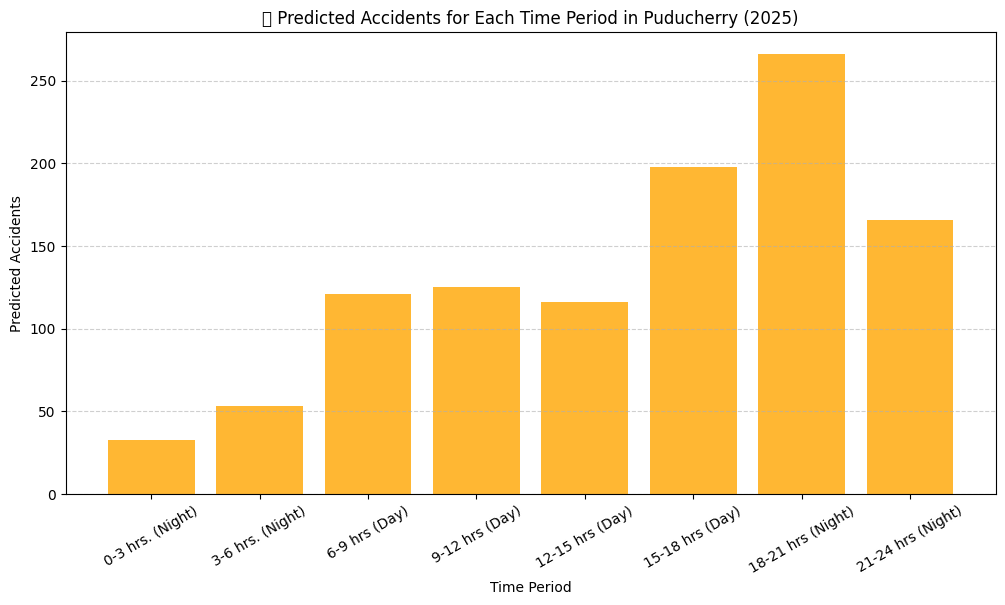


🚦 Predicted Total Accidents in Puducherry for 2025: 1081
⚠️ The time period with the **highest predicted accidents** is **18-21 hrs (Night)** with **266 accidents**.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('only_road_accidents_data3.csv')

# 🔹 Take user input for State & Year
selected_state = input("Enter the State Name: ")
while True:
    try:
        selected_year = int(input("Enter the Year for Prediction: "))
        break
    except ValueError:
        print("Invalid input. Please enter a valid year.")

# 🔹 Filter data for selected state
state_data = df[df['STATE/UT'] == selected_state]

# Ensure enough data exists
if state_data.shape[0] < 5:
    print("⚠️ Not enough data for training.")
    exit()

# Select features & target (Total Accidents)
X = state_data[['YEAR']].values
y_total = state_data[['Total']].values  # Total Accidents

# Scaling
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_x.fit_transform(X)
y_total_scaled = scaler_y.fit_transform(y_total)

# Train model (Linear Regression)
model_total = LinearRegression()
model_total.fit(X_scaled, y_total_scaled)

# Predict total accidents for the selected year
year_test = np.array([[selected_year]])
year_test_scaled = scaler_x.transform(year_test)
y_pred_total_scaled = model_total.predict(year_test_scaled)
y_pred_total = scaler_y.inverse_transform(y_pred_total_scaled.reshape(-1, 1))

# 🔹 Plot the Total Accident Graph
plt.figure(figsize=(10, 5))
plt.bar(state_data['YEAR'], state_data['Total'], color='skyblue', label="Past Data")
plt.bar(selected_year, int(y_pred_total[0][0]), color='red', label="Predicted", alpha=0.8)
plt.xlabel("Year")
plt.ylabel("Total Accidents")
plt.title(f"📊 Accident Trends in {selected_state} (Past & Predicted)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 🔹 Time Period Categories
time_periods = ['0-3 hrs. (Night)', '3-6 hrs. (Night)', '6-9 hrs (Day)', '9-12 hrs (Day)', 
                '12-15 hrs (Day)', '15-18 hrs (Day)', '18-21 hrs (Night)', '21-24 hrs (Night)']

predicted_time_accidents = {}

for period in time_periods:
    y_time = state_data[[period]].values  # Accidents for this time period
    scaler_y_time = StandardScaler()
    y_time_scaled = scaler_y_time.fit_transform(y_time)
    
    model_time = LinearRegression()
    model_time.fit(X_scaled, y_time_scaled)
    
    y_pred_time_scaled = model_time.predict(year_test_scaled)
    y_pred_time = scaler_y_time.inverse_transform(y_pred_time_scaled.reshape(-1, 1))
    
    predicted_time_accidents[period] = int(y_pred_time[0][0])

# 🔹 Identify the time period with the highest predicted accidents
most_dangerous_time = max(predicted_time_accidents, key=predicted_time_accidents.get)
most_accidents = predicted_time_accidents[most_dangerous_time]

# 🔹 Plot Graph for **Historical** Time Period Accidents
plt.figure(figsize=(12, 6))
for period in time_periods:
    plt.plot(state_data['YEAR'], state_data[period], marker='o', label=period)

plt.xlabel("Year")
plt.ylabel("Accidents")
plt.title(f"📊 Historical Accident Trends for Different Time Periods in {selected_state}")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 🔹 Plot Graph for **Predicted** Time Period Accidents
plt.figure(figsize=(12, 6))
plt.bar(time_periods, predicted_time_accidents.values(), color='orange', alpha=0.8)
plt.xlabel("Time Period")
plt.ylabel("Predicted Accidents")
plt.title(f"⏳ Predicted Accidents for Each Time Period in {selected_state} ({selected_year})")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 🔹 Display Results
print(f"\n🚦 Predicted Total Accidents in {selected_state} for {selected_year}: {int(y_pred_total[0][0])}")
print(f"⚠️ The time period with the **highest predicted accidents** is **{most_dangerous_time}** with **{most_accidents} accidents**.")


# Monthly wise Data analysis for road accidents occured from year 2001-2014

In [23]:
# Data extraction
monthly_accident=pd.read_csv('/kaggle/input/road-accidents-in-india/only_road_accidents_data_month2.csv')

**Analysis for year 2014**

In [24]:
df_month=monthly_accident[monthly_accident['YEAR']==2014]
df_month.reset_index(drop=True)

,STATE/UT,YEAR,JANUARY,FEBRUARY,MARCH,APRIL,MAY,JUNE,JULY,AUGUST,SEPTEMBER,OCTOBER,NOVEMBER,DECEMBER,TOTAL
0,A & N Islands,2014,25,13,19,19,18,15,15,16,15,23,18,22,218
1,Andhra Pradesh,2014,3809,3657,3641,3582,3986,3664,3167,3587,3225,3410,3346,4158,43232
2,Arunachal Pradesh,2014,28,10,10,21,9,12,13,14,14,15,22,17,185
3,Assam,2014,658,615,689,612,566,531,573,528,460,670,638,604,7144
4,Bihar,2014,777,742,852,714,985,1002,757,662,685,720,829,806,9531
5,Chandigarh,2014,35,22,31,40,32,25,22,32,38,31,28,30,366
6,Chhattisgarh,2014,1167,1110,1000,1020,1149,1051,934,877,910,1005,973,944,12140
7,D&N Haveli,2014,6,7,7,10,9,4,8,7,7,8,8,6,87
8,Daman & Diu,2014,6,4,3,3,2,2,0,5,1,5,2,6,39
9,Delhi Ut,2014,643,698,801,632,661,658,624,744,742,687,720,700,8310


In [25]:
top_states=df_month.sort_values(by='TOTAL',ascending=False)
top_states.head(3)

,STATE/UT,YEAR,JANUARY,FEBRUARY,MARCH,APRIL,MAY,JUNE,JULY,AUGUST,SEPTEMBER,OCTOBER,NOVEMBER,DECEMBER,TOTAL
433,Tamil Nadu,2014,5658,5293,5824,5303,5711,5915,5719,5936,5777,5516,5036,5562,67250
293,Maharashtra,2014,3978,3714,3920,3847,4258,3784,3546,3450,3298,3291,3478,3818,44382
237,Karnataka,2014,3915,3649,3805,3577,4053,3772,3421,3428,3254,3517,3442,3861,43694


Top three states where maximum accidents occured are Tamil Namdu, Maharashtra, Karnataka.

**Tamil Nadu monthly analysis from year 2001 to 2014**

In [26]:
# For Tamil monthly wise analysis
Tamil_accident=monthly_accident[monthly_accident['STATE/UT']=='Tamil Nadu']
Tamil_accident.head()

,STATE/UT,YEAR,JANUARY,FEBRUARY,MARCH,APRIL,MAY,JUNE,JULY,AUGUST,SEPTEMBER,OCTOBER,NOVEMBER,DECEMBER,TOTAL
420,Tamil Nadu,2001,4174,4264,4724,4442,4465,4453,4370,4437,4378,3985,4261,4025,51978
421,Tamil Nadu,2002,4326,4300,4703,4788,4935,4609,4434,4523,4500,4273,3883,4229,53503
422,Tamil Nadu,2003,4278,4114,4341,3928,4244,4378,4177,4337,4555,4397,3973,4303,51025
423,Tamil Nadu,2004,4160,4252,4457,4421,4540,4495,4373,4696,4506,4282,4136,4190,52508
424,Tamil Nadu,2005,9062,8705,9205,9006,9330,5691,4235,4158,4450,4082,3601,3955,75480


In [27]:
Tamil_accident_melted = Tamil_accident.melt(id_vars=['STATE/UT', 'YEAR'], 
                    value_vars=['JANUARY', 'FEBRUARY', 'MARCH', 'APRIL', 'MAY', 
                                'JUNE', 'JULY', 'AUGUST', 'SEPTEMBER','OCTOBER','NOVEMBER','DECEMBER'],
                    var_name='Month', 
                    value_name='Accidents')

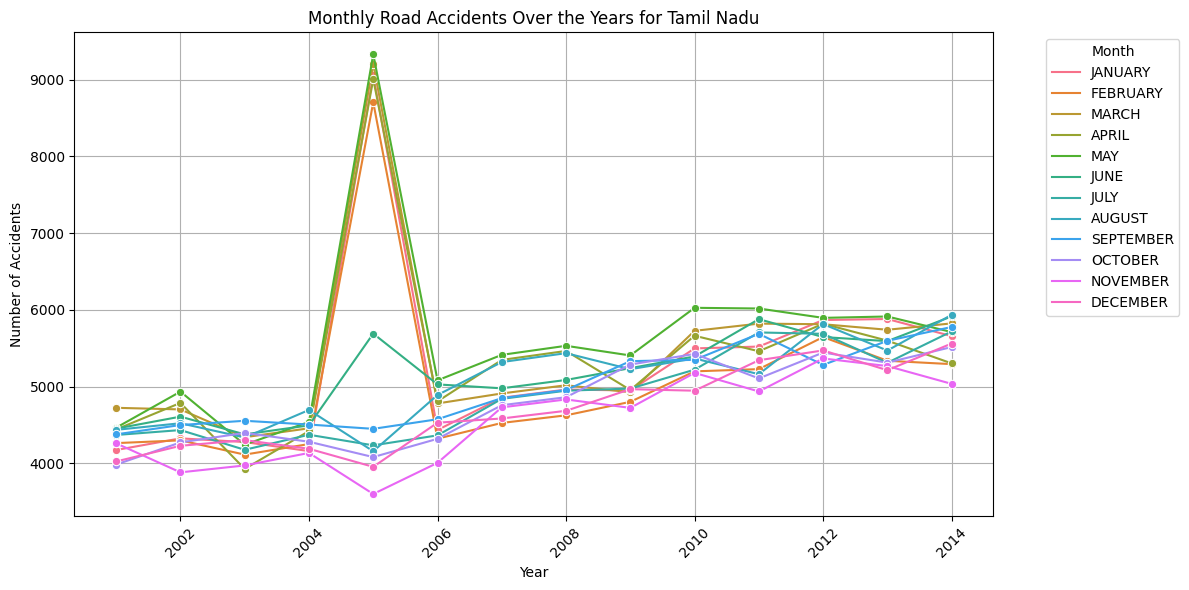

In [28]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='YEAR', y='Accidents',data=Tamil_accident_melted, hue='Month',marker='o')
plt.title('Monthly Road Accidents Over the Years for Tamil Nadu')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

Maximum accidents occured during year 2005 and in May month. Lowest rate of accidents during winter season.

**Maharashtra monthly analysis from year 2001 to2014**

In [29]:
Maha_accident=monthly_accident[monthly_accident['STATE/UT']=='Maharashtra']
Maha_accident.head()

,STATE/UT,YEAR,JANUARY,FEBRUARY,MARCH,APRIL,MAY,JUNE,JULY,AUGUST,SEPTEMBER,OCTOBER,NOVEMBER,DECEMBER,TOTAL
280,Maharashtra,2001,3162,3015,3272,3332,3671,3179,2781,2755,2772,3024,3057,3249,37269
281,Maharashtra,2002,3424,3087,3506,3538,3970,3273,3036,2960,2881,3225,3197,3464,39561
282,Maharashtra,2003,3699,3373,3234,3430,3998,3584,3421,3537,3494,3774,3651,3827,43022
283,Maharashtra,2004,3928,3713,3677,3714,4289,3811,3430,3262,3474,3605,3693,3943,44539
284,Maharashtra,2005,4078,3694,3832,3877,4637,4126,3564,3410,3456,3794,3933,4185,46586


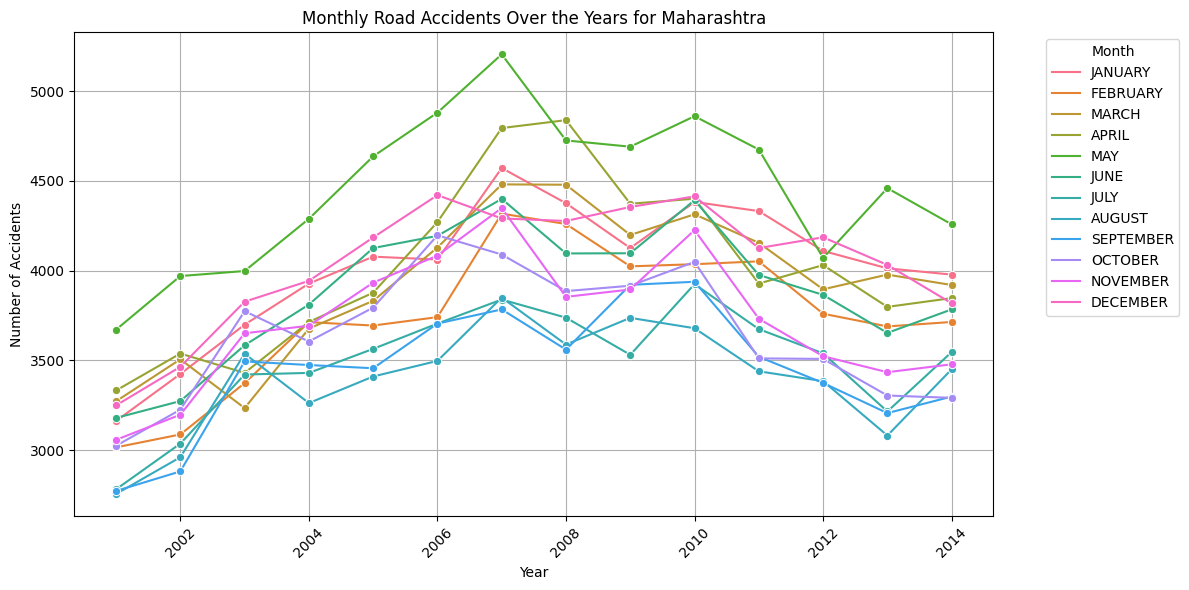

In [30]:
maha_accident_melted = Maha_accident.melt(id_vars=['STATE/UT', 'YEAR'], 
                    value_vars=['JANUARY', 'FEBRUARY', 'MARCH', 'APRIL', 'MAY', 
                                'JUNE', 'JULY', 'AUGUST', 'SEPTEMBER','OCTOBER','NOVEMBER','DECEMBER'],
                    var_name='Month', 
                    value_name='Accidents')
plt.figure(figsize=(12, 6))
sns.lineplot(x='YEAR', y='Accidents',data=maha_accident_melted, hue='Month',marker='o')
plt.title('Monthly Road Accidents Over the Years for Maharashtra')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

For Maharashtra also maximum accidents occur in year 2005. Every year mostly accidents occuring in May month.

**Karnataka state monthly analysis from year 2000 to 2014**

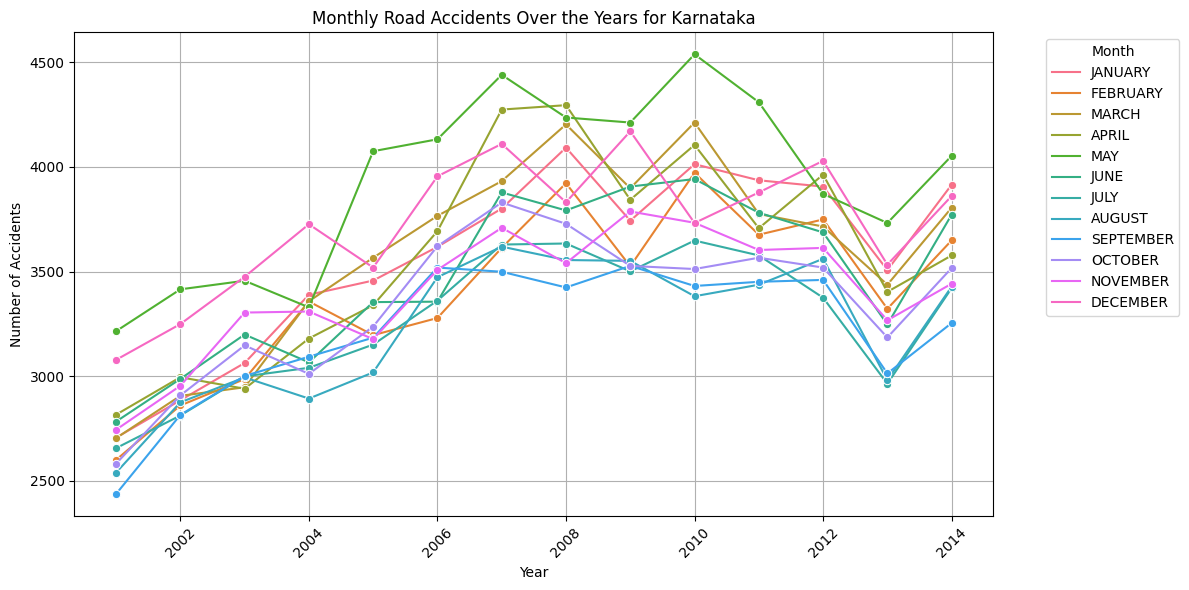

In [31]:
karn_accident=monthly_accident[monthly_accident['STATE/UT']=='Karnataka']
karn_accident_melted = karn_accident.melt(id_vars=['STATE/UT', 'YEAR'], 
                    value_vars=['JANUARY', 'FEBRUARY', 'MARCH', 'APRIL', 'MAY', 
                                'JUNE', 'JULY', 'AUGUST', 'SEPTEMBER','OCTOBER','NOVEMBER','DECEMBER'],
                    var_name='Month', 
                    value_name='Accidents')
plt.figure(figsize=(12, 6))
sns.lineplot(x='YEAR', y='Accidents',data=karn_accident_melted, hue='Month',marker='o')
plt.title('Monthly Road Accidents Over the Years for Karnataka')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

For Karnataka maximum accidents occur in year 2010 and also in may month.

# Location Based data analysis for year 2014-2016

In [32]:
# Extraction of data
location_based_accident=pd.read_csv('/kaggle/input/indian-road-accidents-data/Acc_classified_according_to_Type_of_Location_2014_and_2016.csv')

In [33]:
location_based_accident.head()
# converting all null values to 0 for entire dataset
location_based_accident.fillna(0, inplace=True)
# checking all null values
print(location_based_accident.isnull().sum())


S. No.                                                         0
State/ UT                                                      0
Near School or College - Total Acc. - 2014                     0
Near School or College - Persons Killed - 2014                 0
Near School or College - Persons Injured - 2014                0
                                                              ..
Near or on Road under Construction - Persons Killed - 2016     0
Near or on Road under Construction - Persons Injured - 2016    0
Open Area - Total Accidents - 2016                             0
Open Area - Persons Killed - 2016                              0
Open Area - Persons Injured - 2016                             0
Length: 86, dtype: int64


**Analysis for year 2014**

In [34]:
# Checking all columns present in dataset
location_based_accident.columns

Index(['S. No.', 'State/ UT', 'Near School or College - Total Acc. - 2014',
       'Near School or College - Persons Killed - 2014',
       'Near School or College - Persons Injured - 2014',
       'Near or inside a village - Total Acc. - 2014',
       'Near or inside a village - Persons Killed - 2014',
       'Near or inside a village - Persons Injured - 2014',
       'Near a Factory/Industrial area - Total Acc. - 2014',
       'Near a Factory/Industrial area - Persons Killed - 2014',
       'Near a Factory/Industrial area - Persons Injured - 2014',
       'Near a religious place - Total Acc. - 2014',
       'Near a religious place - Persons Killed - 2014',
       'Near a religious place - Persons Injured - 2014',
       'Near a recreation place/cinema - Total Acc. - 2014',
       'Near a recreation place/cinema - Persons Killed - 2014',
       'Near a recreation place/cinema - Persons Injured - 2014',
       'In bazaar - Total Acc. - 2014', 'In bazaar - Persons Killed - 2014',
      

**Plotting Total accidents occured on basis of location type**

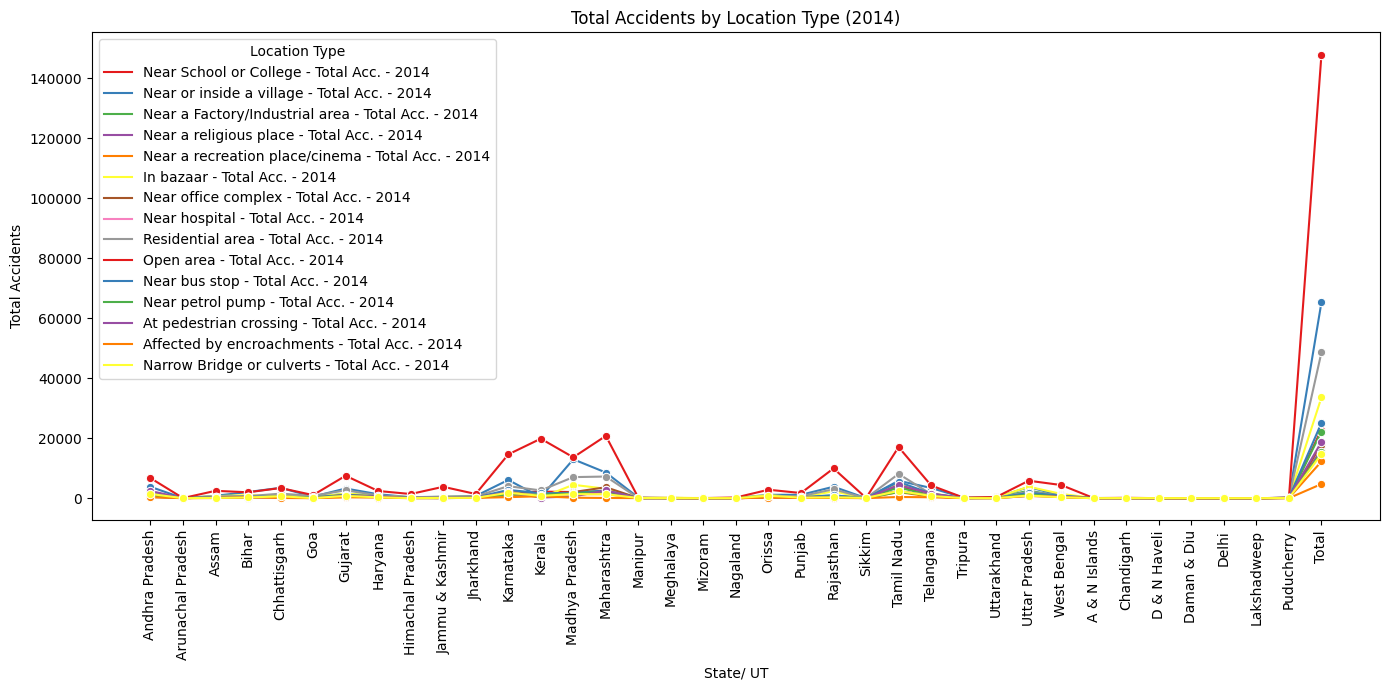

In [35]:
# Reshaping dataset for multiple years
melted_df = location_based_accident.melt(
    id_vars=["State/ UT"],
    value_vars=[
        'Near School or College - Total Acc. - 2014', 
        'Near or inside a village - Total Acc. - 2014', 
        'Near a Factory/Industrial area - Total Acc. - 2014',
        'Near a religious place - Total Acc. - 2014',
        'Near a recreation place/cinema - Total Acc. - 2014',
        'In bazaar - Total Acc. - 2014',
        'Near office complex - Total Acc. - 2014',
        'Near hospital - Total Acc. - 2014',
        'Residential area - Total Acc. - 2014',
        'Open area - Total Acc. - 2014',
        'Near bus stop - Total Acc. - 2014',
        'Near petrol pump - Total Acc. - 2014',
        'At pedestrian crossing - Total Acc. - 2014',
        'Affected by encroachments - Total Acc. - 2014',
        'Narrow Bridge or culverts - Total Acc. - 2014',
    ],
    var_name="Location Type",
    value_name="Total Accidents"
)
plt.figure(figsize=(14, 7))
sns.lineplot(data=melted_df, x="State/ UT", y="Total Accidents", hue="Location Type", palette="Set1",marker='o')
plt.title("Total Accidents by Location Type (2014)")
plt.xticks(rotation=90)
plt.ylabel("Total Accidents")
plt.xlabel("State/ UT")
plt.legend(title="Location Type")
plt.tight_layout()
plt.show()

melted_df: The melt function converts the wide format (columns for each year) into a long format, making it easier to plot the data over time.


Maximum accidents occuring in open area and near school or colleges

**Accidents near School or College**

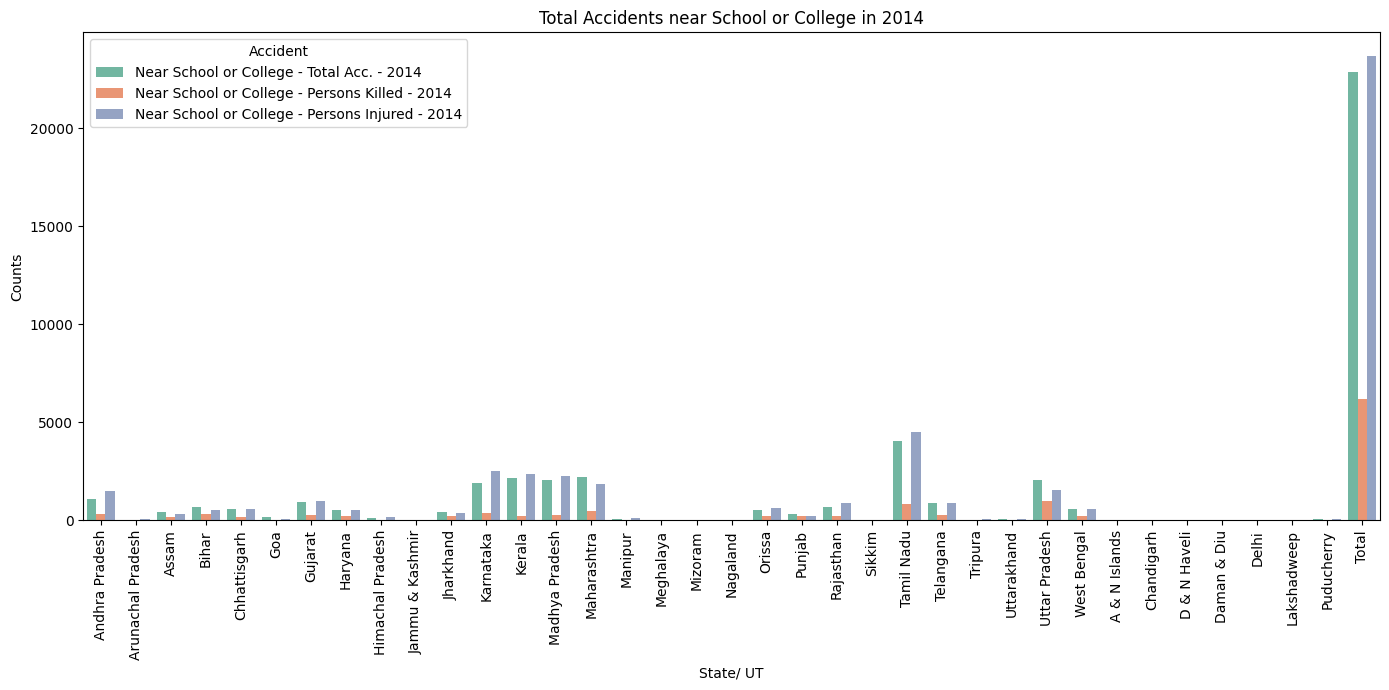

In [36]:
melted_df = location_based_accident.melt(
    id_vars=["State/ UT"],
    value_vars=[
        "Near School or College - Total Acc. - 2014", 
        "Near School or College - Persons Killed - 2014", 
        "Near School or College - Persons Injured - 2014"
    ],
    var_name="Accident",
    value_name="Total Accidents"
)
plt.figure(figsize=(14, 7))
sns.barplot(data=melted_df, x="State/ UT", y="Total Accidents", hue="Accident", palette="Set2")
plt.title("Total Accidents near School or College in 2014")
plt.xticks(rotation=90)
plt.ylabel("Counts")
plt.xlabel("State/ UT")
plt.tight_layout()
plt.show()

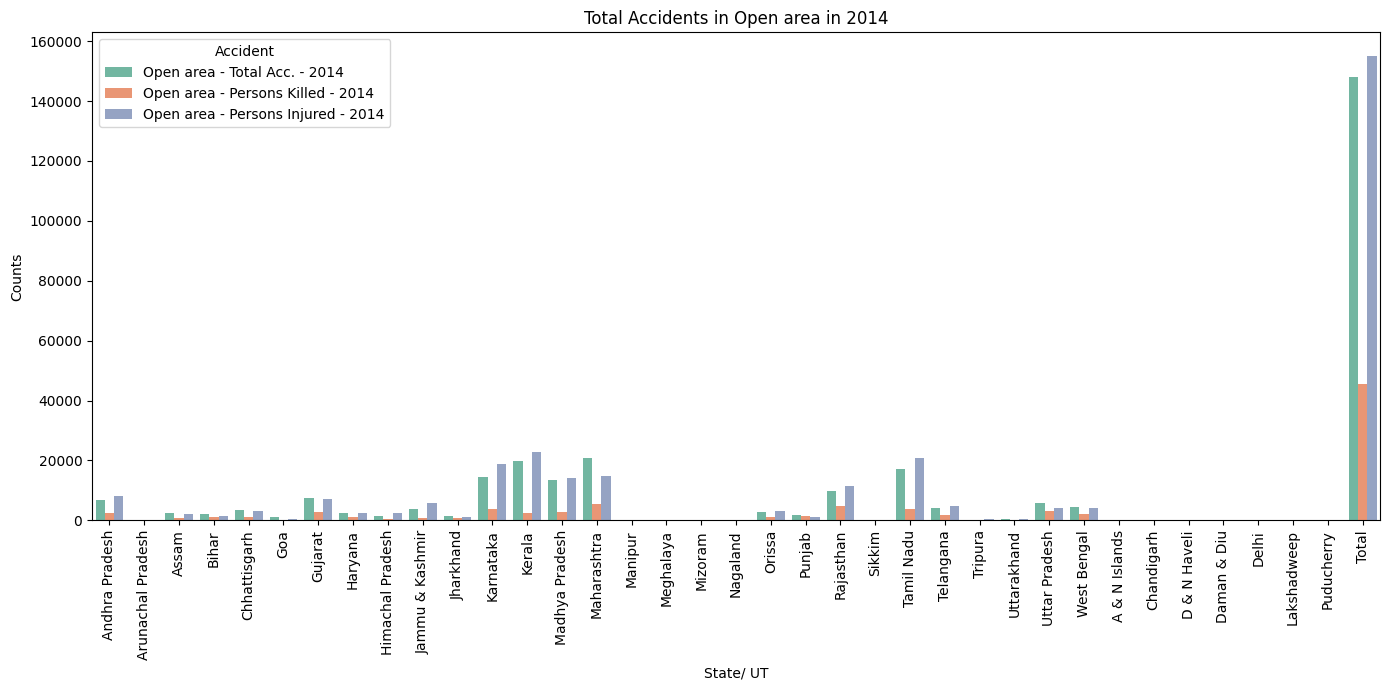

In [37]:
melted_df = location_based_accident.melt(
    id_vars=["State/ UT"],
    value_vars=[
        "Open area - Total Acc. - 2014", 
        "Open area - Persons Killed - 2014", 
        "Open area - Persons Injured - 2014"
    ],
    var_name="Accident",
    value_name="Total Accidents"
)
plt.figure(figsize=(14, 7))
sns.barplot(data=melted_df, x="State/ UT", y="Total Accidents", hue="Accident", palette="Set2")
plt.title("Total Accidents in Open area in 2014")
plt.xticks(rotation=90)
plt.ylabel("Counts")
plt.xlabel("State/ UT")
plt.tight_layout()
plt.show()

# Educational Qualifications of drivers involved in accidents from year 2009-2016

**Drivers who are 10th pass**

In [38]:
# extracting dataset
class10_pass=pd.read_csv('/kaggle/input/indian-road-accidents-data/Accidents_Acc_EduQual_Drivers_above_10_Standard_09-16.csv')

In [39]:
# Seeing first 5 rows of th dataset
class10_pass.head()
# checking null values in the dataset
class10_pass.fillna(0, inplace=True)
class10_pass.isnull().sum()


States/UTs    0
2009          0
2010          0
2011          0
2012          0
2013          0
2014          0
2015          0
2016          0
dtype: int64

**Removing total row from dataset**

In [40]:
class10_pass.dropna(axis=0,inplace=True)
class10_pass.drop(36,inplace=True)

In [41]:
# grouping data on basis of states/UTs 
class10th_pass=class10_pass.groupby(['States/UTs']).sum()
class10th_pass.head()

,2009,2010,2011,2012,2013,2014,2015,2016
States/UTs,,,,,,,,
Andaman & Nicobar Islands,131.0,113.0,103.0,114.0,81.0,82.0,90.0,99.0
Andhra Pradesh,9826.0,7849.0,20150.0,8144.0,12902.0,10485.0,13022.0,10540.0
Arunachal Pradesh,96.0,89.0,86.0,87.0,84.0,83.0,88.0,71.0
Assam,2070.0,0.0,0.0,0.0,2075.0,2629.0,2240.0,1708.0
Bihar,2447.0,3084.0,3810.0,3722.0,3737.0,3826.0,3940.0,2061.0


**Correlation between columns with each other**

**Plotting correlation matrix**

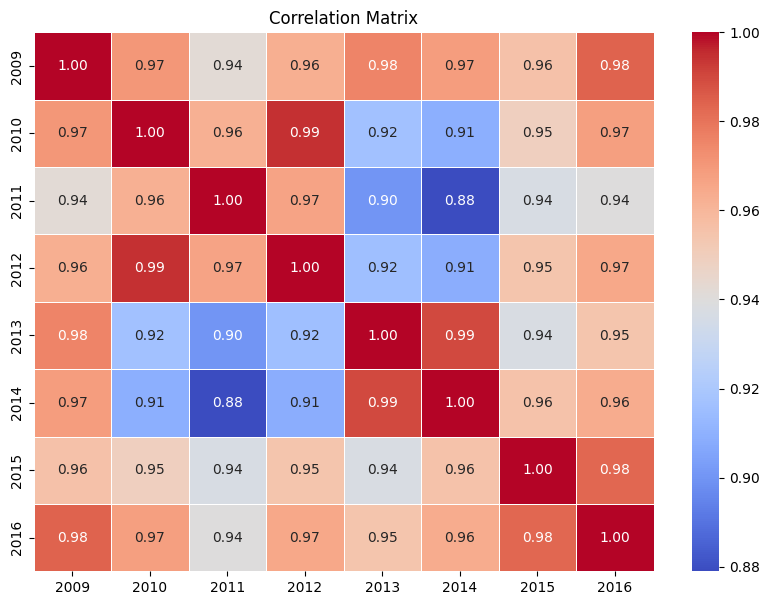

In [42]:
plt.figure(figsize=(10, 7))
correlation_matrix = class10th_pass.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

**Plotting years with states/UTs on single chart**

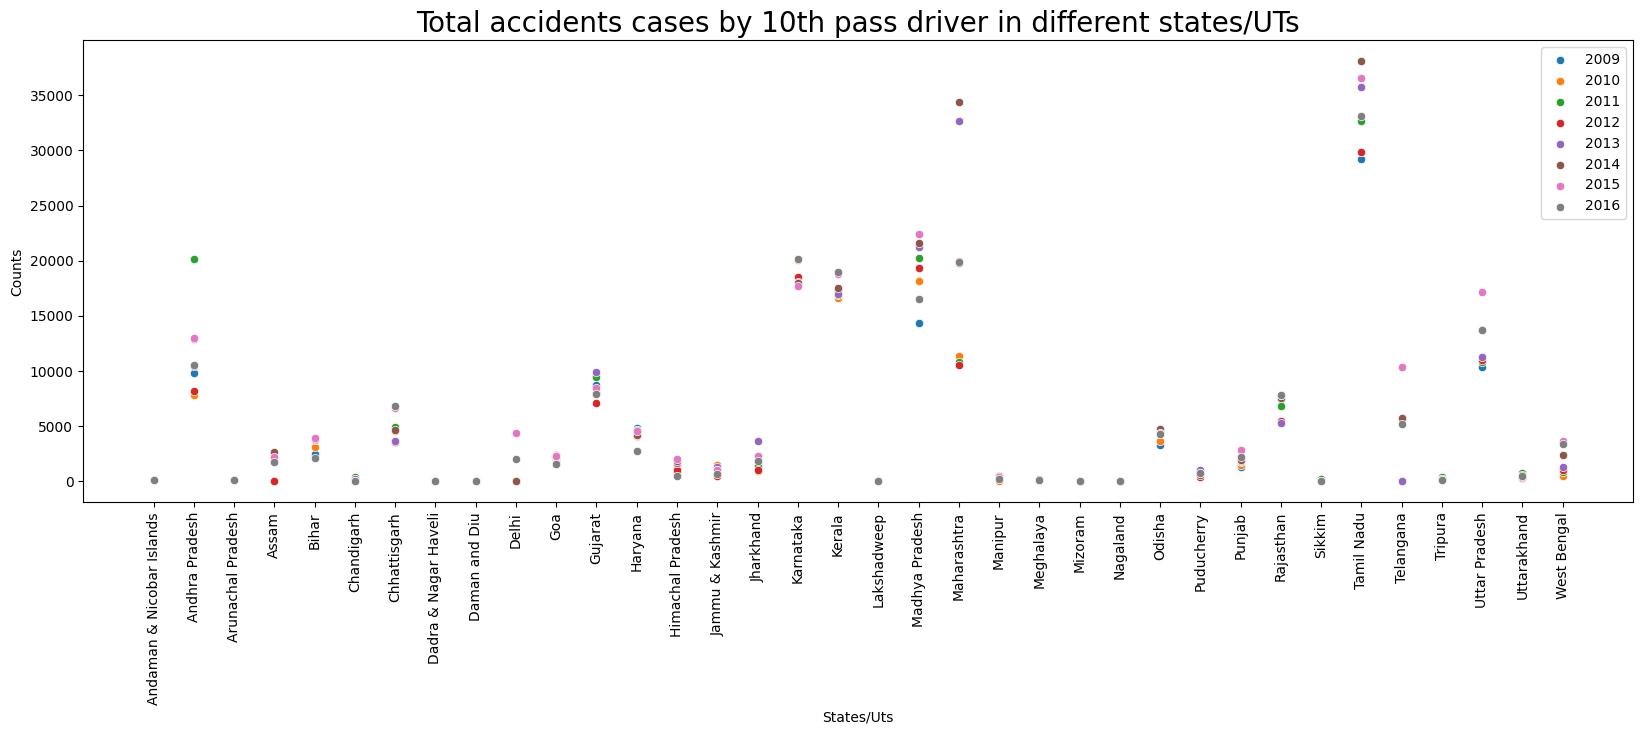

In [43]:
year_column=['2009','2010','2011','2012','2013','2014','2015','2016']
plt.figure(figsize=(20,6))
plt.xlabel('States/Uts')
plt.ylabel('Counts')
plt.title('Total accidents cases by 10th pass driver in different states/UTs',size=20)
plt.xticks(rotation=90)
for col in year_column:
    sns.scatterplot(x='States/UTs',y=col,label=col,data=class10th_pass)
plt.show()

**Plotting year with states/UTs individually**

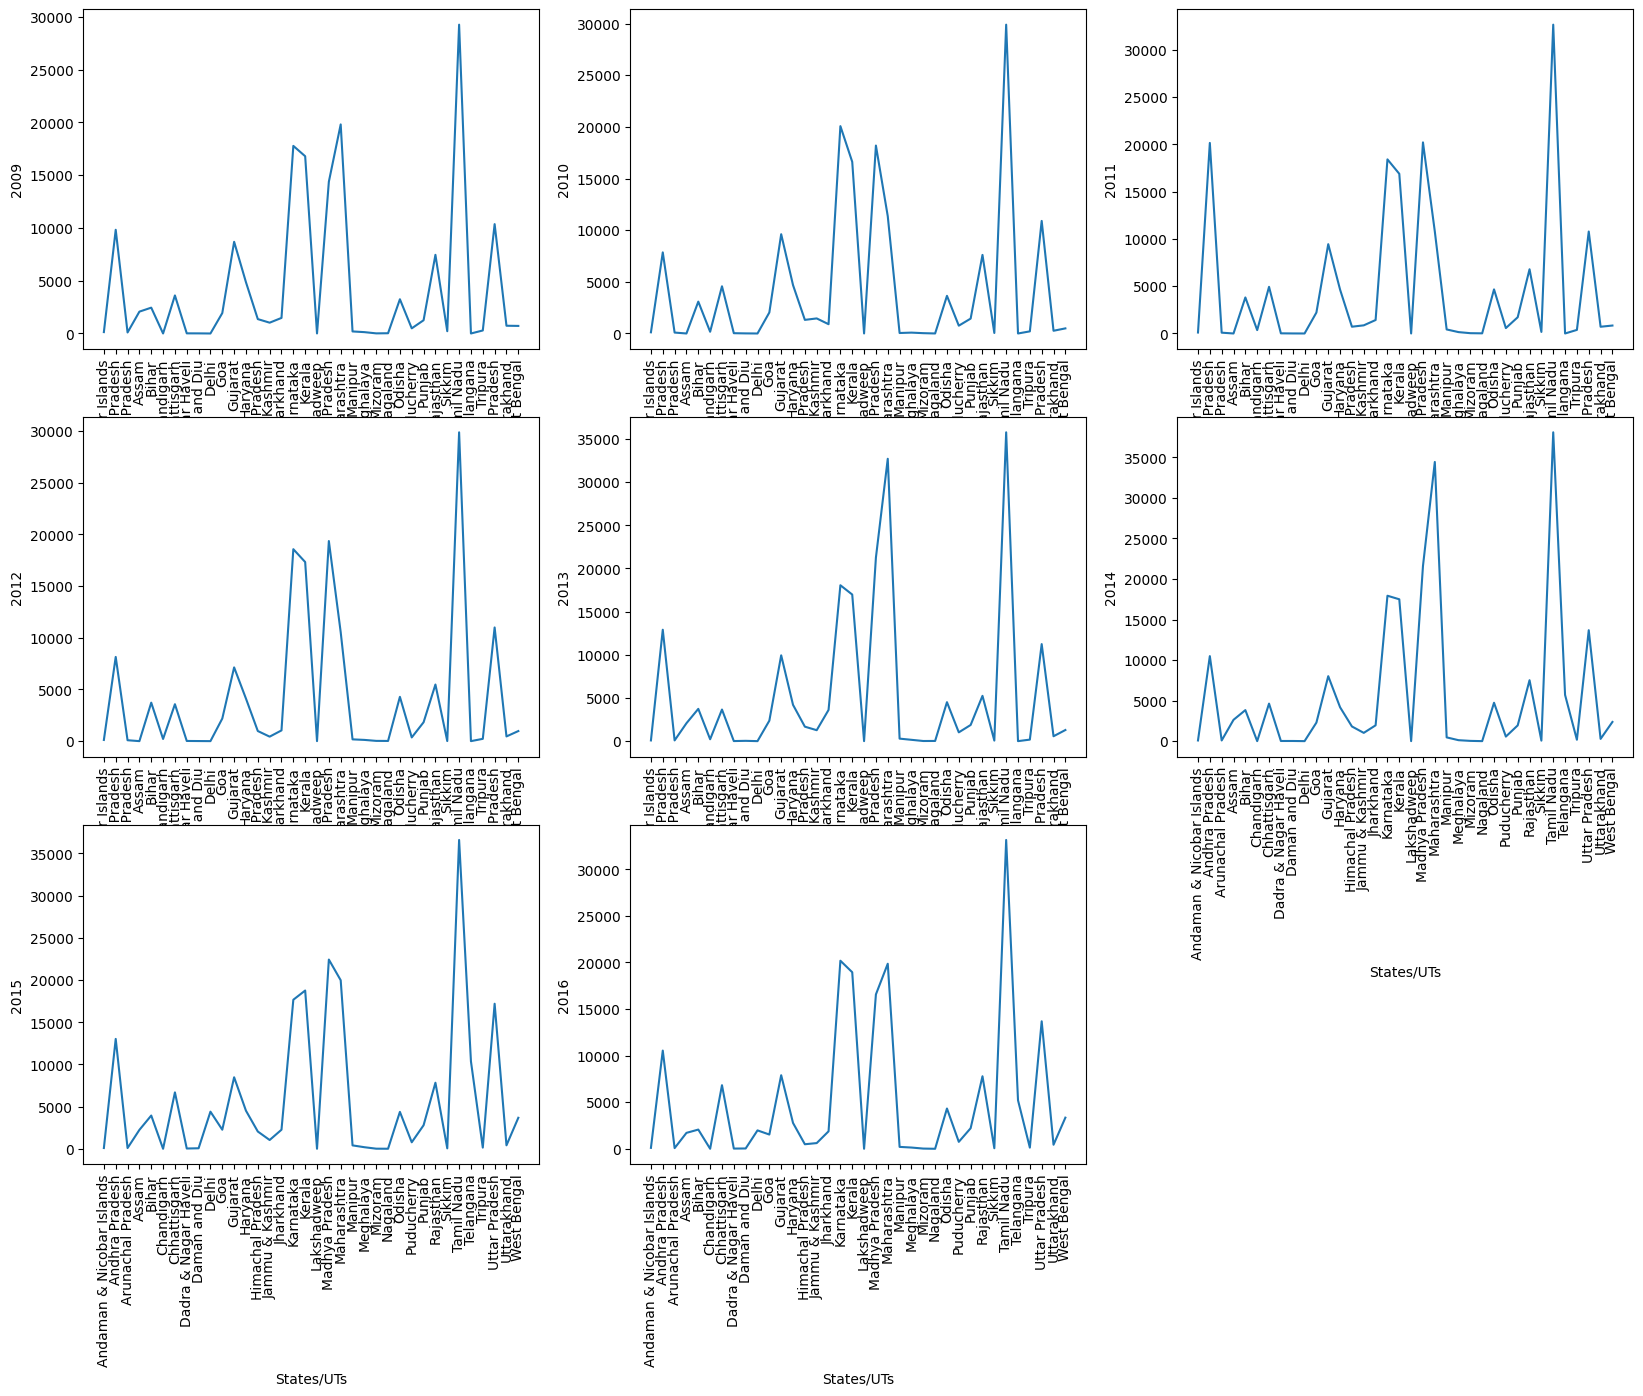

In [44]:
plt.figure(figsize=(20,15))
for i, col in enumerate(year_column,1):
    plt.subplot(3,3,i)
    sns.lineplot(x='States/UTs',y=col,data=class10th_pass)
    plt.xticks(rotation=90)

In [45]:
class10_fail=pd.read_csv('/kaggle/input/indian-road-accidents-data/Accidents_Classified_Acc_To_EduQual_Of_Drivers_9-10_standard-09-16.csv')

In [46]:
# Seeing first 5 rows of th dataset
class10_fail.head()
# checking null values in the dataset
class10_fail.fillna(0, inplace=True)
class10_fail.isnull().sum()

States/UTs    0
2009          0
2010          0
2011          0
2012          0
2013          0
2014          0
2015          0
2016          0
dtype: int64

In [47]:
class10_fail.dropna(axis=0,inplace=True)
class10_fail.drop(36,inplace=True)

In [48]:
class10th_fail=class10_fail.groupby(['States/UTs']).sum()
class10th_fail.head()

,2009,2010,2011,2012,2013,2014,2015,2016
States/UTs,,,,,,,,
Andaman and Nicobar Islands,102.0,114.0,126.0,104.0,93.0,114.0,96.0,115.0
Andhra Pradesh,9882.0,8040.0,13550.0,8657.0,17170.0,7941.0,6333.0,7111.0
Arunachal Pradesh,107.0,90.0,113.0,76.0,131.0,61.0,104.0,69.0
Assam,1704.0,0.0,0.0,0.0,2554.0,2547.0,2498.0,2936.0
Bihar,3273.0,5200.0,4136.0,3938.0,3761.0,3643.0,2981.0,2400.0


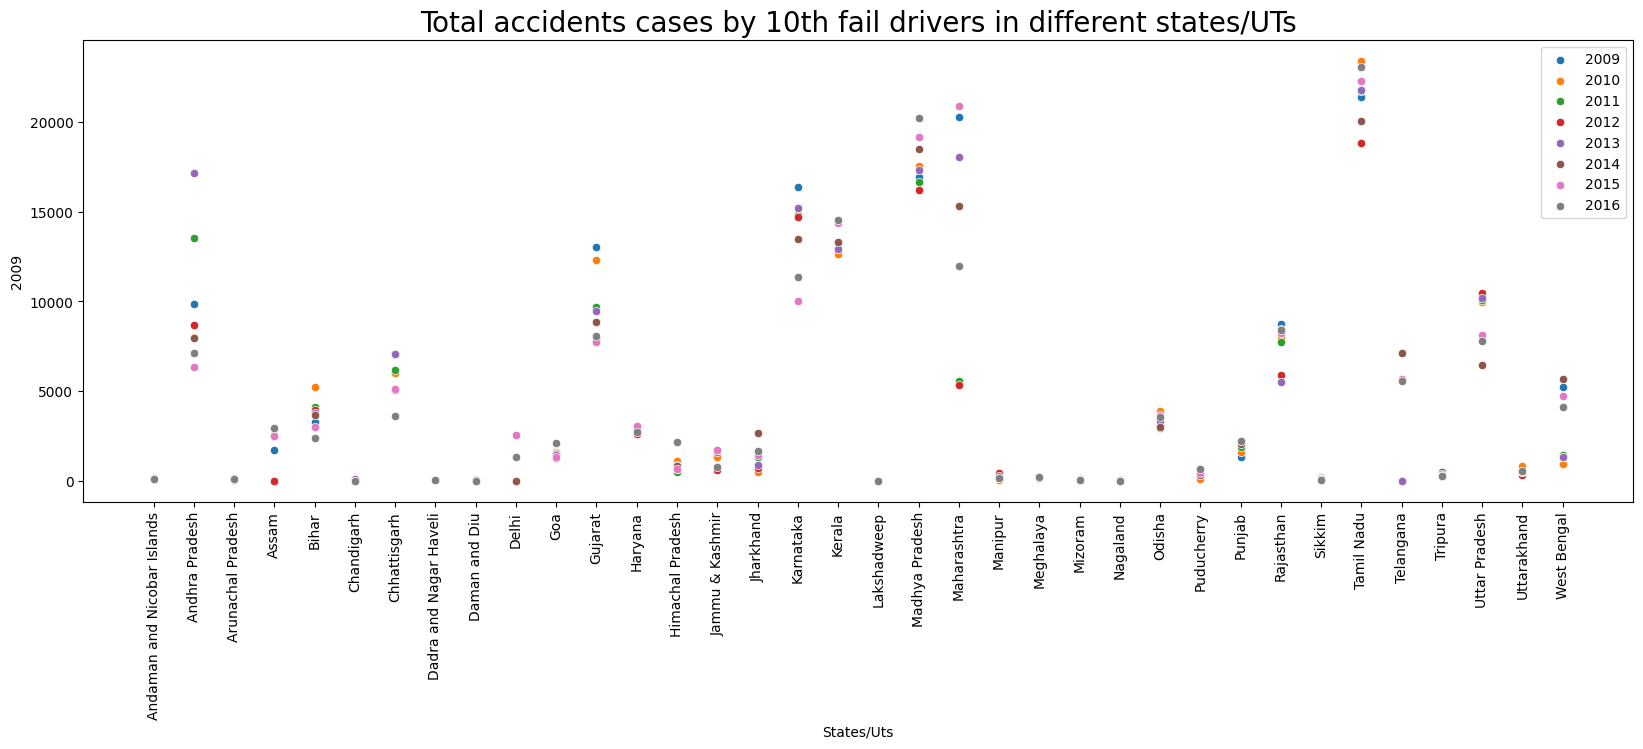

In [49]:
plt.figure(figsize=(20,6))
plt.xlabel('States/Uts')
plt.xticks(rotation=90)
plt.title('Total accidents cases by 10th fail drivers in different states/UTs',size=20)
for col in year_column:
    sns.scatterplot(x='States/UTs',y=col,label=col,data=class10th_fail,marker='o')
plt.show()

Analysis for 2014 year 

In [50]:
df_10pass=class10_pass.loc[:,['States/UTs','2014']]
df_10pass=df_10pass.rename(columns={'2014':'10th pass'})

In [51]:
df_10fail=class10_fail.loc[:,['States/UTs','2014']]
df_10fail=df_10fail.rename(columns={'2014':'10th fail'})

In [52]:
df_edu=df_10pass.copy()
df_edu['10th fail']=df_10fail['10th fail']
df_edu['total']=df_edu['10th pass']+df_edu['10th fail']
df_edu=df_edu.sort_values(by='total',ascending=False)
df_edu.head()

,States/UTs,10th pass,10th fail,total
23,Tamil Nadu,38094.0,20067.0,58161.0
14,Maharashtra,34437.0,15343.0,49780.0
13,Madhya Pradesh,21608.0,18525.0,40133.0
11,Karnataka,17936.0,13488.0,31424.0
12,Kerala,17497.0,13320.0,30817.0


In Tamil Nadu, under both 10th pass and 10th fail criteria, the accidents are higher.
Top 3 states are Tamil Nadu,

# Accidents case due to different age group

In [53]:
agewise_accident=pd.read_csv('/kaggle/input/indian-road-accidents-data/No_of_Road_Acc_acco_to_clf_of_age_of_Driver_2014_2016.csv')

In [54]:
agewise_accident.head()
# checking missing values
agewise_accident.isnull().sum()

S. No.                                   0
State/ UT                                0
0-14                                     0
15-24                                    0
25-64                                    0
64 above                                 0
Age Less than 18 years - Fatal - 2016    0
Age Less than 18 years - Total - 2016    0
Age 18-25 - Fatal - 2016                 0
Age 18-25 - Total - 2016                 0
Age 25-35 - Fatal - 2016                 0
Age 25-35 - Total - 2016                 0
Age 35-45 - Fatal - 2016                 0
Age 35-45 - Total - 2016                 0
Age 45-60 - Fatal - 2016                 0
Age 45-60 - Total - 2016                 0
Age 60 and Above - Fatal - 2016          0
Age 60 and Above - Total - 2016          0
Age Age not known - Fatal - 2016         0
Age Age not known - Total - 2016         0
dtype: int64

In [55]:
agewise_accident.describe()

,0-14,15-24,25-64,64 above,Age Less than 18 years - Fatal - 2016,Age Less than 18 years - Total - 2016,Age 18-25 - Fatal - 2016,Age 18-25 - Total - 2016,Age 25-35 - Fatal - 2016,Age 25-35 - Total - 2016,Age 35-45 - Fatal - 2016,Age 35-45 - Total - 2016,Age 45-60 - Fatal - 2016,Age 45-60 - Total - 2016,Age 60 and Above - Fatal - 2016,Age 60 and Above - Total - 2016,Age Age not known - Fatal - 2016,Age Age not known - Total - 2016
count,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000
mean,56.378378,1009.837838,1841.783784,148.432432,290.972973,1012.864865,1657.351351,6219.081081,2013.621622,7088.756757,1677.891892,5768.972973,928.864865,3391.675676,243.513514,891.459459,542.972973,1608.378378
std,177.643424,3062.136976,5600.916191,455.158064,901.359667,3119.375286,5013.941925,18868.772226,6091.107897,21574.715658,5078.072030,17567.206789,2816.932563,10359.023997,739.555671,2731.175516,1642.147180,4871.706935
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,10.000000,18.000000,0.000000,2.000000,5.000000,25.000000,104.000000,30.000000,171.000000,22.000000,92.000000,14.000000,39.000000,1.000000,5.000000,2.000000,4.000000
50%,1.000000,252.000000,237.000000,10.000000,24.000000,137.000000,663.000000,1439.000000,765.000000,1602.000000,401.000000,1281.000000,143.000000,439.000000,34.000000,101.000000,138.000000,381.000000
75%,20.000000,780.000000,1517.000000,114.000000,164.000000,560.000000,1255.000000,5282.000000,1433.000000,6479.000000,1287.000000,5211.000000,845.000000,2824.000000,206.000000,630.000000,412.000000,1365.000000
max,1043.000000,18682.000000,34073.000000,2746.000000,5383.000000,18738.000000,30661.000000,115053.000000,37252.000000,131142.000000,31041.000000,106726.000000,17184.000000,62746.000000,4505.000000,16492.000000,10045.000000,29755.000000


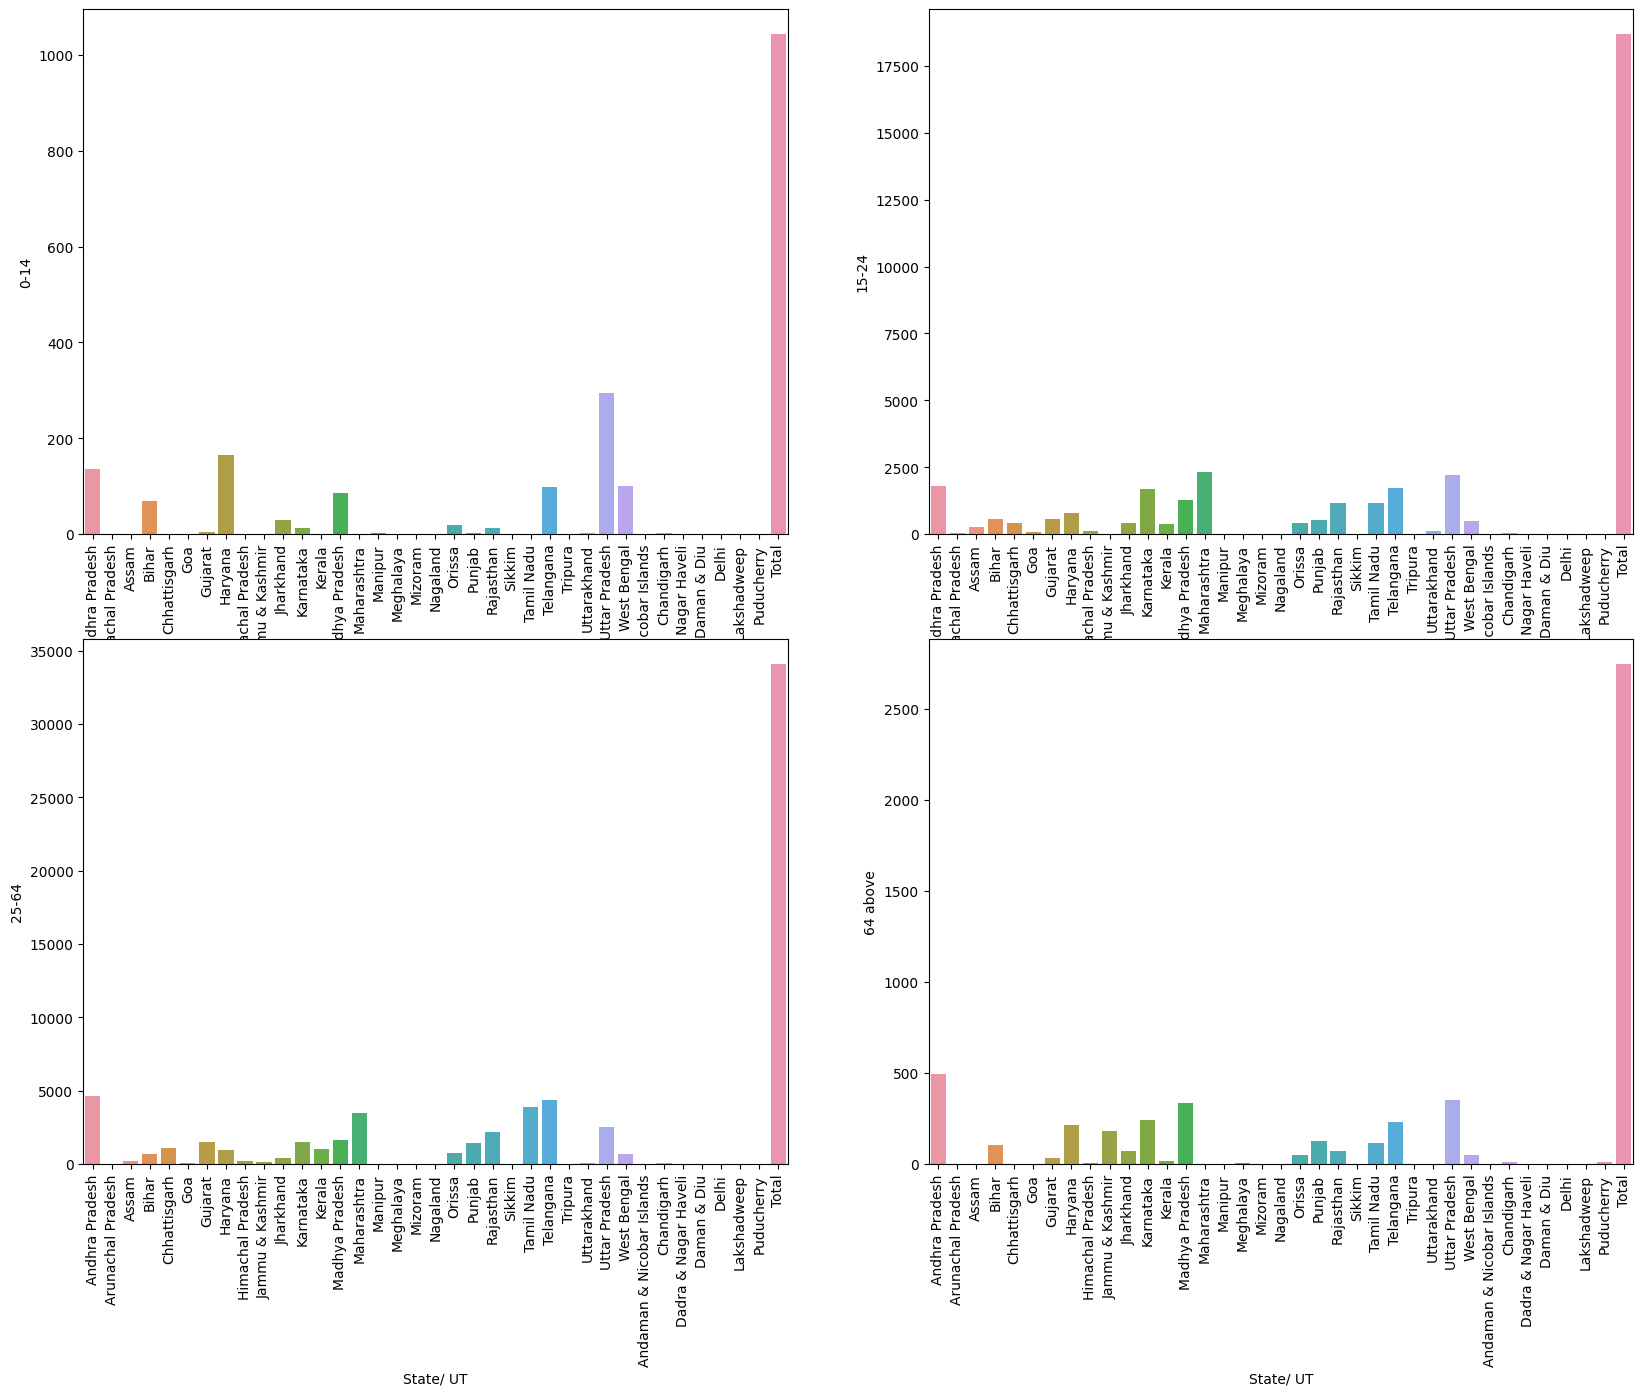

In [56]:
age_group=['0-14','15-24','25-64','64 above']
plt.figure(figsize=(20,15))
for i,col in enumerate(age_group,1):
    plt.subplot(2,2,i)
    sns.barplot(x='State/ UT',y=col,data=agewise_accident)
    plt.xticks(rotation=90)

Q.Which age group has the highest number of accidents?

A.25-64 age group has the highest number of accidents mainly in Andhra pradesh followed by Telangana and Tamil Nadu.

# Conclusion 

This is a brief dataset analysis using 5 different datasets based on ,daily analysis,monthly analysis ,locationa based, education qualification of drivers and different age groups of drivers.
